#### Case: Isobaric evaporation of ammonia in a large tank for long-term storage


In [19]:
# Ensure that python finds the submodules
import sys
sys.path.append("..") # Adds higher directory to python modules path.

# Scientific computing
import numpy as np

# Visualisation
import matplotlib.pyplot as plt

## Module imports
# Import the storage tank Class
from cryoevap.storage_tanks import Tank

# Import Cryogen class
from cryoevap.cryogens import Cryogen

# Import Pandas for data handling
import pandas as pd


#### Setup tank and cryogen properties

In [8]:
# LNG tank properties
Q_roof = 0           # Roof heat ingress / W
d_i    = 10.24*2     # Internal diameter / m
d_o    = 10.6972*2   # External diameter / m
T_air  = 5.3286+273.15 # Temperature of the environment K

# Set overall heat transfer coefficient through the walls for liquid and vapour
U_L = 0.087   # W/m2/K
U_V = 0.087   # W/m2/K
h_L = 124.96  # W/m2/K

# Set wall tank properties
Init_T = True   # True: T_air, False: T_L
k_w    = 0.0411 # W/mK
cp_w   = 900    # J/kg K
rho_w  = 60     # kg/m3

# Specify heat transfer rate at the bottom to prevent ground heating
Q_b = 0 # W, 

# Vertically orientated cylindrical tank volume
V_tank = 5059.889 #m^3

# Initial liquid filling / Dimensionless
LF = 0.95 

# Specify tank operating pressure
P = 101325 # Pa

# Initialize large-scale tank
large_tank = Tank(d_i, d_o, V_tank, LF)

large_tank.set_HeatTransProps(U_L, U_V, T_air, Q_b_fixed = Q_b, Q_roof = 0, eta_w = 0.70, k_w = k_w, rho_w = rho_w, cp_w = cp_w, h_L = h_L, T_init = Init_T)

# Initialise cryogen
ammonia = Cryogen(name = "ammonia")
ammonia.set_coolprops(P)

# Set cryogen
large_tank.cryogen = ammonia

# Calculate initial evaporation rate
print("The initial evaporation rate of " + ammonia.name + " is %.1f kg/h" % (large_tank.b_l_dot * 3600))

The initial evaporation rate of ammonia is 9.0 kg/h


Calculate initial evaporation rate and transient period

In [9]:
# Calculate initial evaporation rate
print("The initial evaporation rate of " + ammonia.name + " is %.1f kg/h" % (large_tank.b_l_dot * 3600))

# Estimate transient period duration
print("Transient period = %.3f s " % large_tank.tau)

# Minimum number of hours to achieve steady state 
tau_h = (np.floor(large_tank.tau / 3600) + 1)

# Print simulation time of the transient period for short-term storage
print("Simulation time: %.0i h" % tau_h )

# Calculate boil-off rate
BOR = (large_tank.b_l_dot * 24 * 3600) / (large_tank.V * large_tank.LF * large_tank.cryogen.rho_L)
print("BOR = %.3f %%" % (BOR * 100))

The initial evaporation rate of ammonia is 9.0 kg/h
Transient period = 180406.152 s 
Simulation time: 51 h
BOR = 0.007 %


#### Setup environmental properties

In [10]:
T_env_avg = 5.3286+273.15     # K
T_range   = 15                # K
h_env     = 396               # W/m2K   

p_anual   = np.array([-0.00022, 0.08395, 0.989792])

large_tank.set_EnvironmentalProps(T_avg_day = T_env_avg, T_range_day = T_range, h_env = h_env,
                                  p_anual=None)

#### Simulation setup and execution

In [11]:
# Define vertical spacing
dz = 0.05
dr = 0.01

# Calculate number of nodes
n_z = 1 + int(np.round(large_tank.l_V/dz, 0))
n_r = 1 + int(np.round((large_tank.d_o - large_tank.d_i)/(2*dr), 0))

# Define dimensionless computational grid
large_tank.z_grid = np.linspace(0, 1, n_z)

large_tank.r_grid = np.linspace(0, 1, n_r)

# Insulated roof
large_tank.U_roof = 0

# Define evaporation time as 48 weeks
evap_time = 3600 * 24 * 7

# Time step to record data, relevant for plotting integrated quantities
# such as the vapour to liquid heat transfer rate, Q_VL
large_tank.time_interval = 3600 * 1 

# Time step to plot each vapour temperature profile
large_tank.plot_interval = evap_time/6

# Simulate the evaporation
large_tank.evaporate(evap_time)

In [ ]:
# Exportar resultados a CSV
l_V = large_tank.l -large_tank.data['V_L']/large_tank.A_T
z_V = large_tank.z_grid[:, np.newaxis] * l_V[np.newaxis, :]

T_V_df = pd.DataFrame(
    large_tank.data['T_V_raw'],
    columns=[f"t = {t} s" for t in large_tank.data['Time']]
)

z_V_df = pd.DataFrame(
    z_V,
    columns=[f"t = {t} s" for t in large_tank.data['Time']]
)

T_w_df = pd.DataFrame(
    np.column_stack([
        large_tank.r_grid * (large_tank.d_o - large_tank.d_i) / 2,
        large_tank.data['T_w_raw']
    ]),
    columns=['r_grid'] + [f"t = {t} s" for t in large_tank.data['Time']]
)

# Export data to CSV files
T_V_df.to_csv('T_V.csv', index=False)
z_V_df.to_csv('z_V.csv', index=False)
T_w_df.to_csv('T_w.csv', index=False)

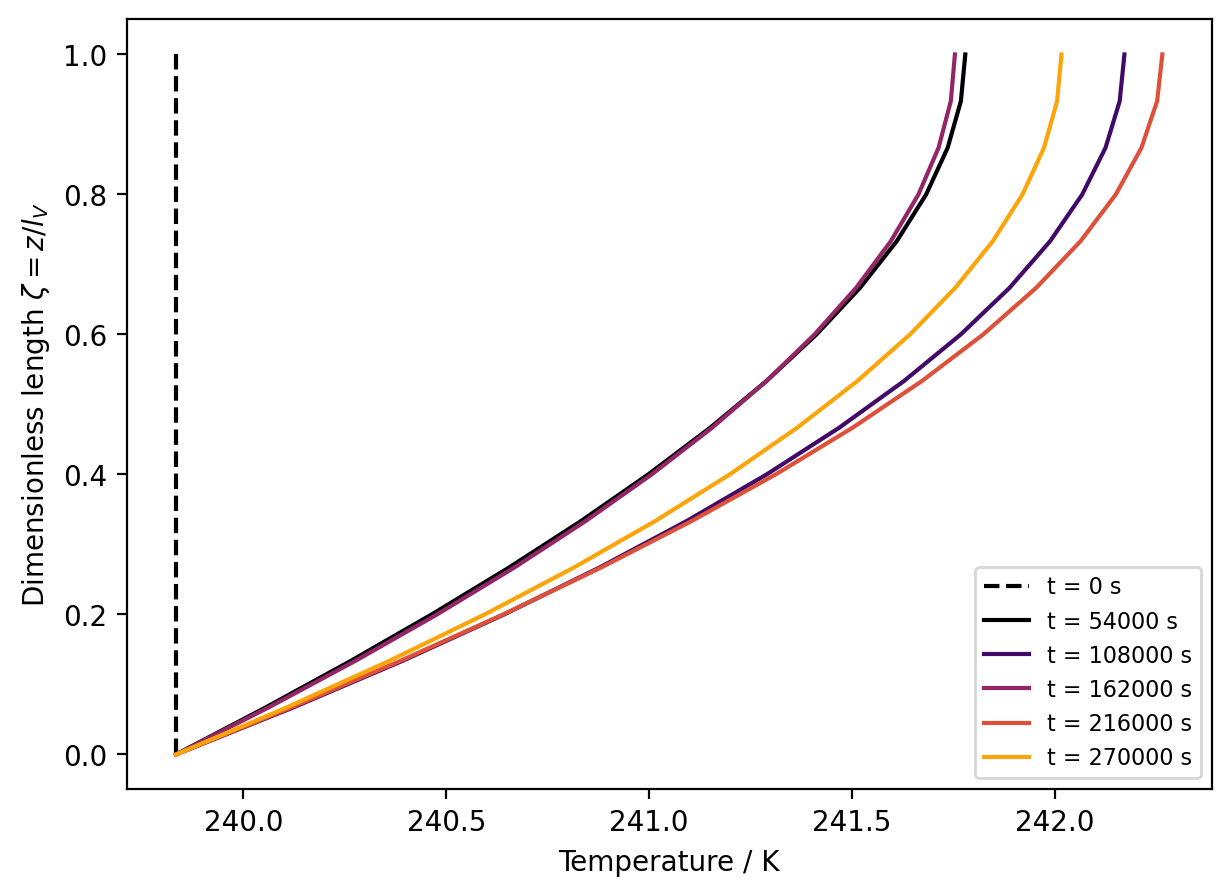

In [86]:
T_V_csv = pd.read_csv('T_V.csv')
z_grid  = np.linspace(0, 1, T_V_csv.shape[0])
selected_index = [15, 30, 45, 60, 75]  # Indices of the times to plot

# Crear mapa de colores
cmap = plt.get_cmap('inferno', len(selected_index)+1)

# Crear figura
fig, ax = plt.subplots(figsize=[7, 5], dpi = 200)

# Graficar condición inicial
T_init = T_V_csv.iloc[:, 0]
ax.plot(T_init, z_grid, '--k', label='t = 0 s')

# Graficar curvas de temperatura para los tiempos seleccionados
for i in range(len(selected_index)):
    # Graficar con color correspondiente al tiempo
    ax.plot(T_V_csv.iloc[:, selected_index[i]], z_grid, color=cmap(i), label = T_V_csv.columns[selected_index[i]])


# Configuración del gráfico
ax.legend(loc='lower right', fontsize=8)
ax.set_ylabel(r'Dimensionless length $\zeta = z/l_V$')
ax.set_xlabel('Temperature / K')

plt.show()

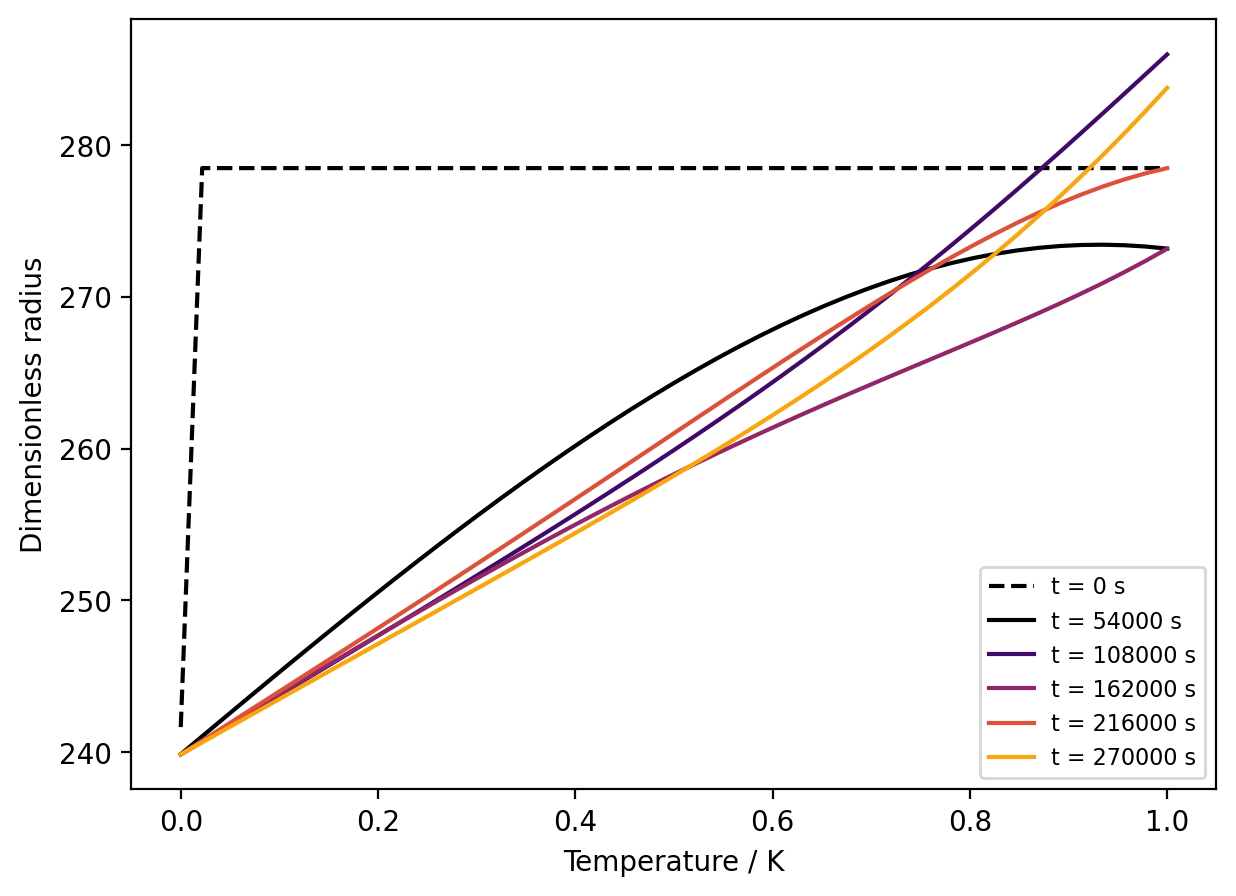

In [ ]:
T_w_csv = pd.read_csv('T_w.csv')
r_grid  = np.linspace(0, 1, T_w_csv.shape[0])

selected_index = [15, 30, 45, 60, 75]  # Indices a graficar (posiciones dentro del dataframe).
                                       # Si deseas seleccionar por nombre de columna, cambiar a loc en vez de iloc

# Crear mapa de colores
cmap = plt.get_cmap('inferno', len(selected_index)+1)

# Crear figura
fig, ax = plt.subplots(figsize=[7, 5], dpi = 200)

# Graficar condición inicial
T_init = T_w_csv.iloc[:, 1]
ax.plot(r_grid, T_init, '--k', label='t = 0 s')

# Graficar curvas de temperatura para los tiempos seleccionados
for i in range(len(selected_index)):
    ax.plot(r_grid, T_w_csv.iloc[:, selected_index[i]+1], color=cmap(i), label = T_w_csv.columns[selected_index[i]+1])

# Configuración del gráfico
ax.legend(loc='lower right', fontsize=8)
ax.set_ylabel(r'Dimensionless radius')
ax.set_xlabel('Temperature / K')

plt.show()

#### Visualisation of results

#### Vapour temperature

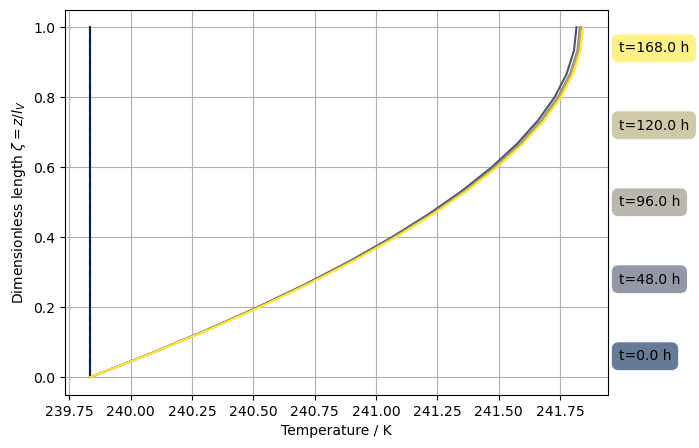

In [21]:
# Visualise the plot
large_tank.plot_tv(t_unit='h')

Visualise liquid and vapour heat ingresses, $\dot{Q}_{\text{L}}$ and  $\dot{Q}_{\text{V}}$.

The plot also shows the vapour to liquid heat ingress, $\dot{Q}_{VL}$, and  the partition of the vapour heat ingress that is transferred to the interface by the wall directly, $\dot{Q}_{\text{V,w}}$

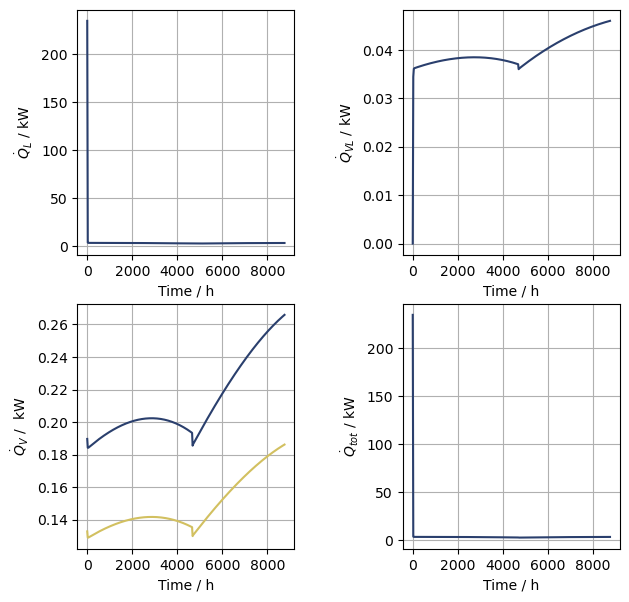

In [15]:
large_tank.plot_Q(unit='kW', t_unit='h')

#### Plot liquid volume

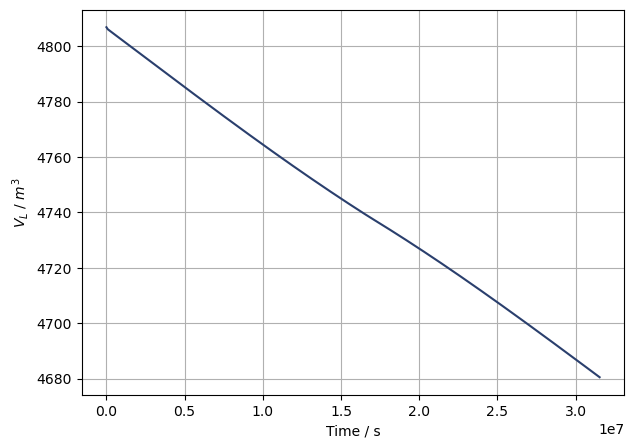

In [16]:
large_tank.plot_V_L()

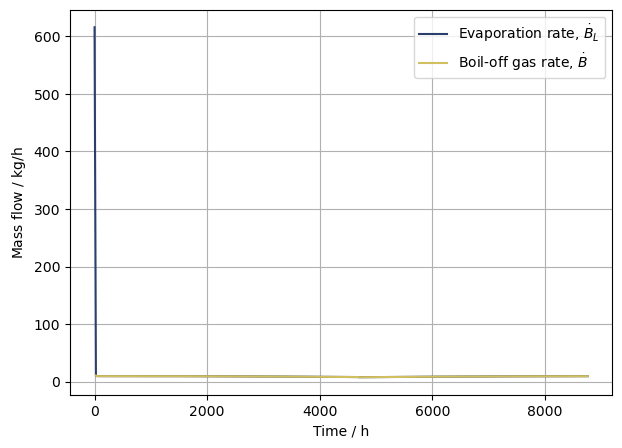

In [17]:
large_tank.plot_BOG(unit='kg/h', t_unit='h')

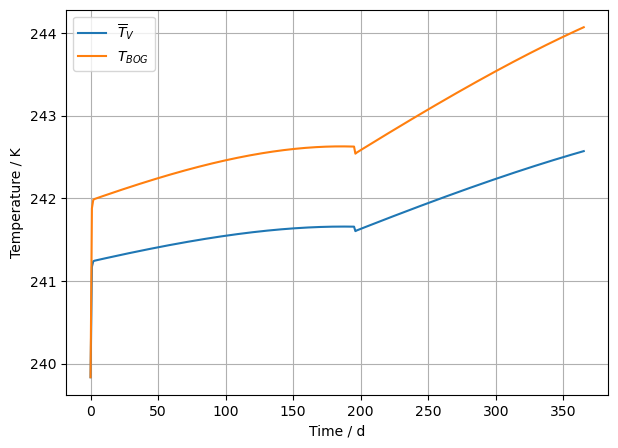

In [18]:
large_tank.plot_tv_BOG(t_unit='d')

#### Plot wall properties

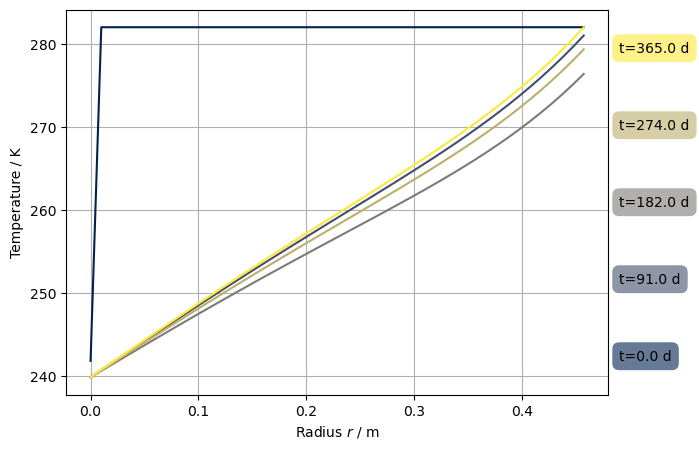

In [11]:
# Using real EDO
large_tank.plot_tw(t_unit='d')


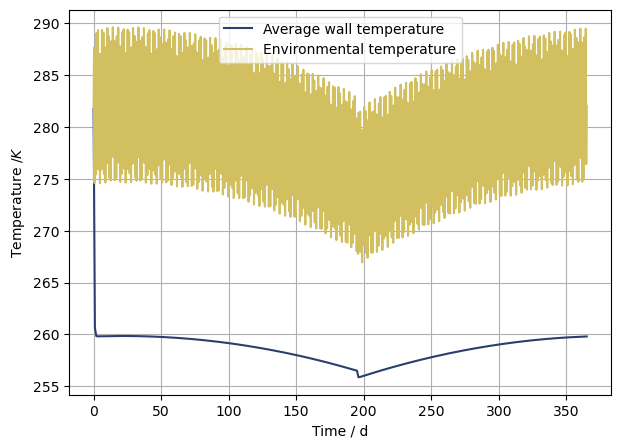

In [12]:
large_tank.plot_T_w_avg(t_unit='d')

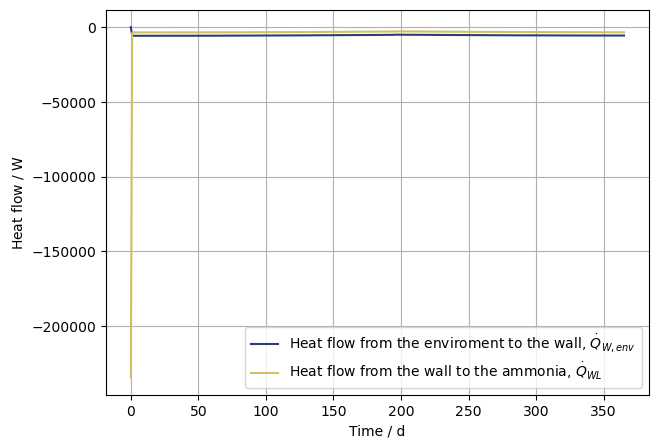

In [13]:
large_tank.plot_Q_w(unit='W', t_unit='d')


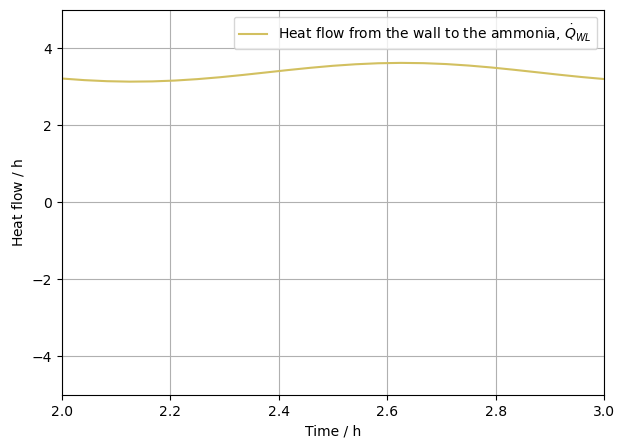

In [14]:
# Time unit conversion factor for plotting
t_dict = {'s':1, 'min': 60, 'h':3600, 'd': 3600*24, 'w': 3600*24*7}

unit_conv = {'W': 1, 'kW': 1e-3}
cmap = plt.get_cmap('cividis')
area_ext = large_tank.d_o * large_tank.l * np.pi
area_int = large_tank.d_i * large_tank.l * np.pi

# Extract evaporation and BOG rates and convert to kg/h
# Visualise evaporation and boil-off gas rate in kg/h
plt.figure(figsize=[7, 5])
# plt.plot(large_tank.sol.t/t_dict['d'], large_tank.data['Q_env_w']*unit_conv['W']/area_ext , label=r'Heat flow from the enviroment to the wall, $\dot{Q}_{W,env}$', color = cmap(1/6))
plt.plot(large_tank.sol.t/t_dict['d'], large_tank.data['Q_L'] *unit_conv['W']/area_int, label=r'Heat flow from the wall to the ammonia, $\dot{Q}_{WL}$', color = cmap(5/6)) 
plt.grid()
plt.ylim([-5,5])
plt.xlabel('Time / ' + 'h')
plt.xlim([2,3])
plt.ylabel(r'Heat flow $/$ ' + 'h')
plt.legend()

In [15]:
# Calcular t_eval:
t_ast = np.linspace(0, 10, 101)
t_eval = t_ast * 4.8 *3600
# Llamar al integrador
# large_tank.evaporate(t_eval)
large_tank.evaporate(evap_time)

# Extraer variables
# print(large_tank.data['T_w_raw'])
# print(large_tank.data['t_raw'])
print(large_tank.data['T_V'])
# Exportarlo en csv: preguntar chatgpt

[239.83431862 240.079153   240.3089496  240.52372544 240.72342061
 240.9079008  241.07695939 241.23031992 241.3676384  241.48850548
 241.59244841 241.67893271 241.74736331 241.79708523 241.82738365
 241.83748312]


In [16]:
# Export the arrays for 
# np.savetxt("Temperaturas.csv", large_tank.data['T_w_raw'], delimiter=",", fmt="%f")
# np.savetxt("Tiempos.csv", large_tank.data['t_raw'], delimiter=",", fmt="%f")
# np.savetxt("T_vapor.csv", large_tank.data['T_V'], delimiter=",", fmt="%f")

In [17]:
np.savetxt("Temperaturas1.csv", large_tank.data['T_w_raw'], delimiter=",", fmt="%f")
np.savetxt("Tiempos1.csv", large_tank.data['t_raw'], delimiter=",", fmt="%f")
np.savetxt("T_vapor1.csv", large_tank.data['T_V'], delimiter=",", fmt="%f")


#### References



F. Huerta, V. Vesovic, A realistic vapour phase heat transfer model for the weathering of LNG stored in large tanks, Energy, 174 (2019) 280-291.